<a href="https://colab.research.google.com/github/Ariefnaufal67/metopen/blob/main/Metopen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

METOPEN UNTUK BAB 3

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
!pip install imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [ ]:
print(f"📊 Dataset berhasil dimuat!")
print(f"   Jumlah data  : {df.shape[0]} baris")
print(f"   Jumlah fitur : {df.shape[1]} kolom")
df.head()


📊 Dataset berhasil dimuat!
   Jumlah data  : 1200 baris
   Jumlah fitur : 13 kolom


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory 

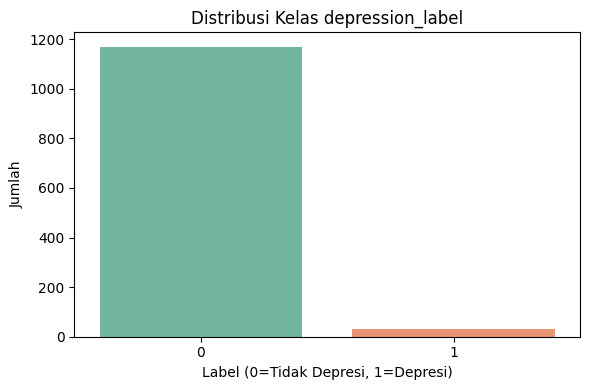


⚠️  Data sangat tidak seimbang (1169 vs 31) → akan ditangani dengan SMOTE


In [ ]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUSI LABEL ===")
print(df['depression_label'].value_counts())
print("  0 = Tidak Depresi | 1 = Depresi")

# Visualisasi distribusi label
plt.figure(figsize=(6, 4))
sns.countplot(x='depression_label', data=df, palette='Set2')
plt.title('Distribusi Kelas depression_label')
plt.xlabel('Label (0=Tidak Depresi, 1=Depresi)')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150)
plt.show()
print("\n⚠️  Data sangat tidak seimbang (1169 vs 31) → akan ditangani dengan SMOTE")

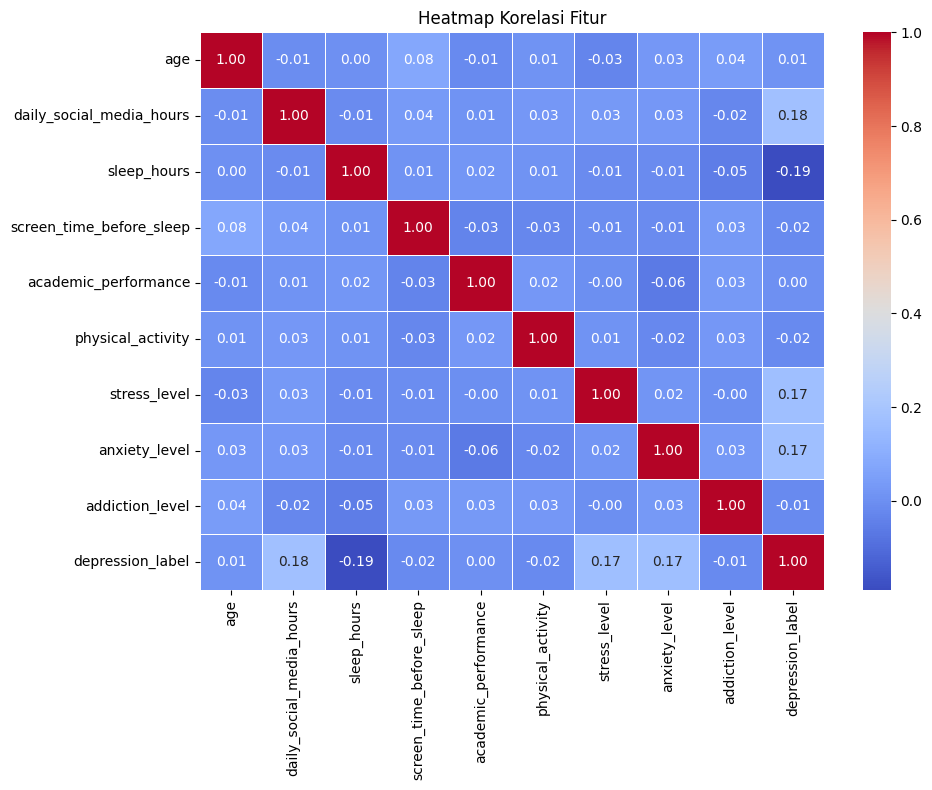

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()

In [ ]:
df_clean = df.copy()

# Encoding fitur kategorikal
le = LabelEncoder()
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Pisahkan fitur dan target
X = df_clean.drop('depression_label', axis=1)
y = df_clean['depression_label']

print(f"\nFitur (X): {X.shape[1]} kolom")
print(f"Target (y): {y.value_counts().to_dict()}")


Encoded 'gender': {'female': np.int64(0), 'male': np.int64(1)}
Encoded 'platform_usage': {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}
Encoded 'social_interaction_level': {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Fitur (X): 12 kolom
Target (y): {0: 1169, 1: 31}


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Sebelum SMOTE : {dict(pd.Series(y).value_counts())}")
print(f"Sesudah SMOTE : {dict(pd.Series(y_resampled).value_counts())}")

Sebelum SMOTE : {0: np.int64(1169), 1: np.int64(31)}
Sesudah SMOTE : {0: np.int64(1169), 1: np.int64(1169)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print(f"Data Train : {X_train.shape[0]} data")
print(f"Data Test  : {X_test.shape[0]} data")

# Normalisasi (wajib untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Data Train : 1870 data
Data Test  : 468 data


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest selesai ditraining!")

✅ Random Forest selesai ditraining!


In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    class_weight='balanced'
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print("✅ SVM selesai ditraining!")

✅ SVM selesai ditraining!


In [ ]:
def evaluasi_model(nama, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"{'='*45}")
    print(f"  HASIL EVALUASI: {nama}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Tidak Depresi', 'Depresi']))
    return {'Model': nama, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

hasil_rf  = evaluasi_model("Random Forest", y_test, y_pred_rf)
hasil_svm = evaluasi_model("SVM",           y_test, y_pred_svm)

  HASIL EVALUASI: Random Forest
  Accuracy  : 1.0000 (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      1.00      1.00       234
      Depresi       1.00      1.00      1.00       234

     accuracy                           1.00       468
    macro avg       1.00      1.00      1.00       468
 weighted avg       1.00      1.00      1.00       468

  HASIL EVALUASI: SVM
  Accuracy  : 0.9936 (99.36%)
  Precision : 0.9873
  Recall    : 1.0000
  F1-Score  : 0.9936

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      0.99      0.99       234
      Depresi       0.99      1.00      0.99       234

     accuracy                           0.99       468
    macro avg       0.99      0.99      0.99       468
 weighted avg       0.99      0.99      0.99       468



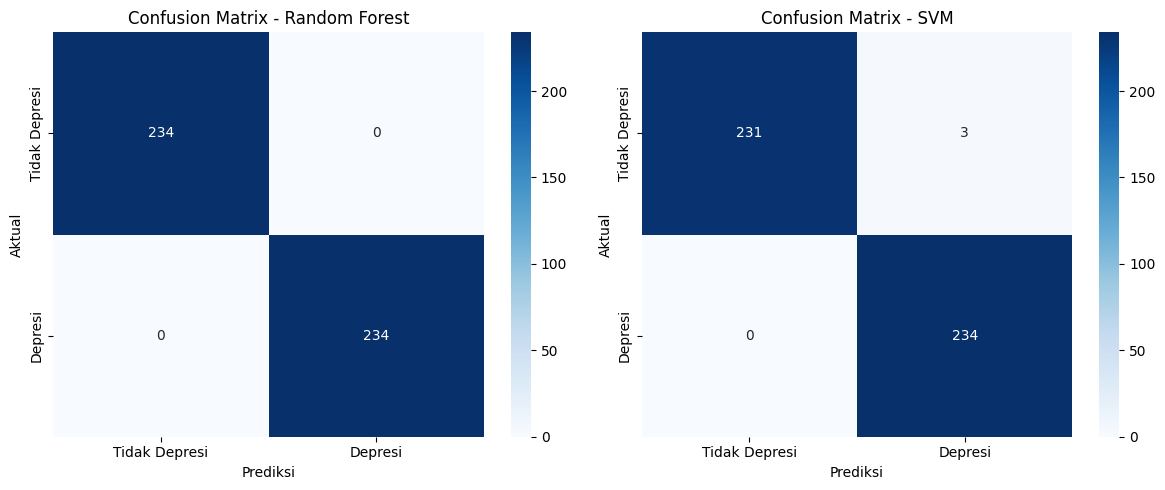

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nama, y_pred) in zip(axes, [
    ("Random Forest", y_pred_rf),
    ("SVM",           y_pred_svm)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Depresi','Depresi'],
                yticklabels=['Tidak Depresi','Depresi'])
    ax.set_title(f'Confusion Matrix - {nama}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

=== TABEL PERBANDINGAN MODEL ===
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest   1.00000   1.000000     1.0  1.000000
SVM             0.99359   0.987342     1.0  0.993631


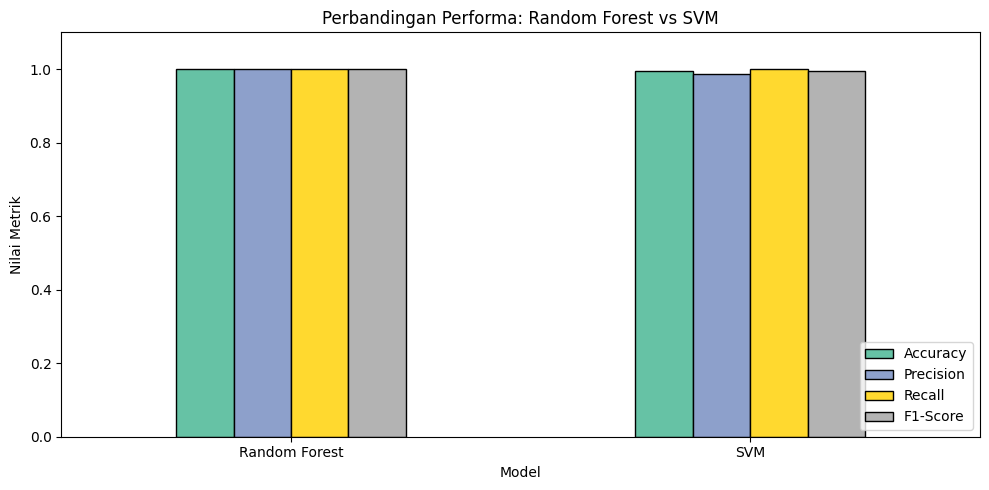

In [ ]:
df_hasil = pd.DataFrame([hasil_rf, hasil_svm]).set_index('Model')
print("=== TABEL PERBANDINGAN MODEL ===")
print(df_hasil.to_string())

df_hasil.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa: Random Forest vs SVM')
plt.ylabel('Nilai Metrik')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150)
plt.show()

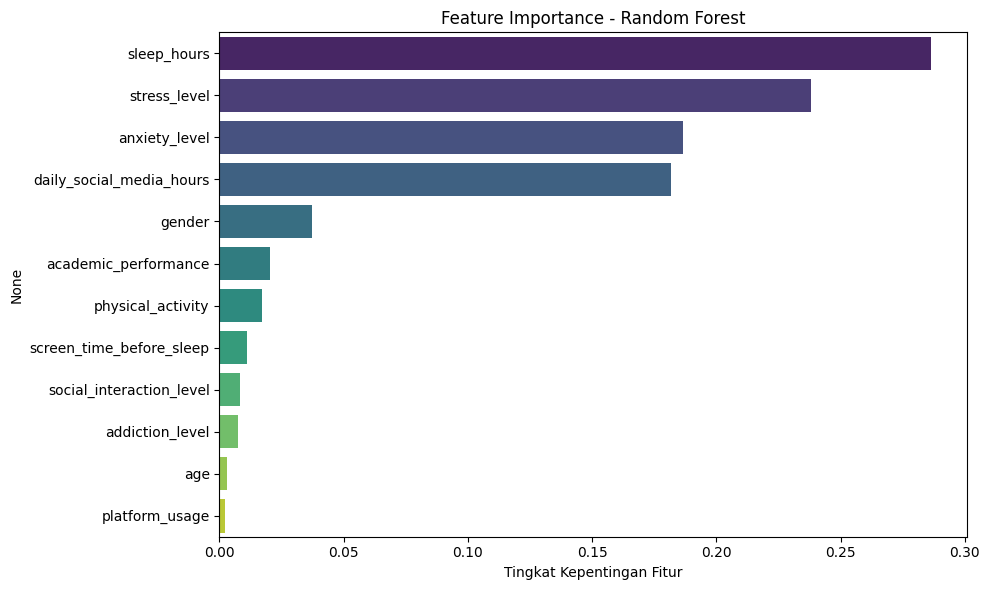


=== FITUR PALING BERPENGARUH ===
   sleep_hours                    : 0.2865
   stress_level                   : 0.2380
   anxiety_level                  : 0.1865
   daily_social_media_hours       : 0.1819
   gender                         : 0.0373
   academic_performance           : 0.0204
   physical_activity              : 0.0170
   screen_time_before_sleep       : 0.0111
   social_interaction_level       : 0.0081
   addiction_level                : 0.0076
   age                            : 0.0030
   platform_usage                 : 0.0024


In [ ]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n=== FITUR PALING BERPENGARUH ===")
for feat, val in feat_imp.items():
    print(f"   {feat:<30} : {val:.4f}")

In [ ]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_rf  = cross_val_score(rf_model,  X_resampled, y_resampled, cv=kfold, scoring='f1')
cv_svm = cross_val_score(svm_model, X_resampled, y_resampled, cv=kfold, scoring='f1')

print(f"Random Forest  → F1 rata-rata: {cv_rf.mean():.4f} (±{cv_rf.std():.4f})")
print(f"SVM            → F1 rata-rata: {cv_svm.mean():.4f} (±{cv_svm.std():.4f})")


Random Forest  → F1 rata-rata: 0.9996 (±0.0013)
SVM            → F1 rata-rata: 0.9735 (±0.0116)


In [ ]:
print("="*50)
print("  KESIMPULAN AKHIR")
print("="*50)
best = df_hasil['Accuracy'].idxmax()
print(f"\n✅ Model terbaik: {best}")
print(f"   Accuracy  : {df_hasil.loc[best, 'Accuracy']*100:.2f}%")
print(f"   Precision : {df_hasil.loc[best, 'Precision']*100:.2f}%")
print(f"   Recall    : {df_hasil.loc[best, 'Recall']*100:.2f}%")
print(f"   F1-Score  : {df_hasil.loc[best, 'F1-Score']*100:.2f}%")

print("\n📁 Grafik tersimpan:")
for f in ['distribusi_label.png','heatmap_korelasi.png','confusion_matrix.png','perbandingan_model.png','feature_importance.png']:
    print(f"   - {f}")


  KESIMPULAN AKHIR

✅ Model terbaik: Random Forest
   Accuracy  : 100.00%
   Precision : 100.00%
   Recall    : 100.00%
   F1-Score  : 100.00%

📁 Grafik tersimpan:
   - distribusi_label.png
   - heatmap_korelasi.png
   - confusion_matrix.png
   - perbandingan_model.png
   - feature_importance.png


PENAMBAHAN ALGORITMA

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset.csv


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [6]:
# ── GOOGLE COLAB ──────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # upload Teen_Mental_Health_Dataset.csv
# df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# ── ANACONDA / LOKAL ──────────────────────────────────────────────
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')   # sesuaikan path jika perlu

print(f"📊 Dataset berhasil dimuat!")
print(f"   Jumlah data  : {df.shape[0]} baris")
print(f"   Jumlah fitur : {df.shape[1]} kolom")
df.head()

📊 Dataset berhasil dimuat!
   Jumlah data  : 1200 baris
   Jumlah fitur : 13 kolom


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory 

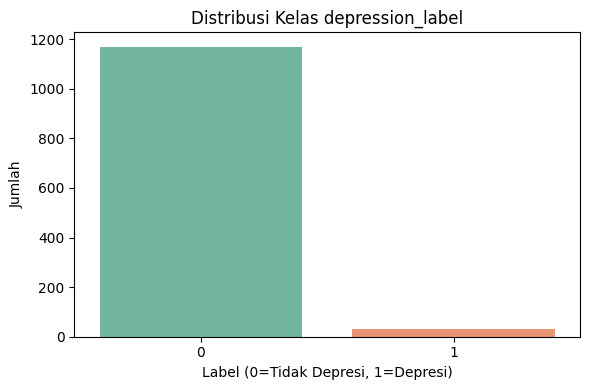


⚠️  Data sangat tidak seimbang (1169 vs 31) → akan ditangani dengan SMOTE


In [8]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUSI LABEL ===")
print(df['depression_label'].value_counts())
print("  0 = Tidak Depresi | 1 = Depresi")

# Visualisasi distribusi label
plt.figure(figsize=(6, 4))
sns.countplot(x='depression_label', data=df, palette='Set2')
plt.title('Distribusi Kelas depression_label')
plt.xlabel('Label (0=Tidak Depresi, 1=Depresi)')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150)
plt.show()
print("\n⚠️  Data sangat tidak seimbang (1169 vs 31) → akan ditangani dengan SMOTE")

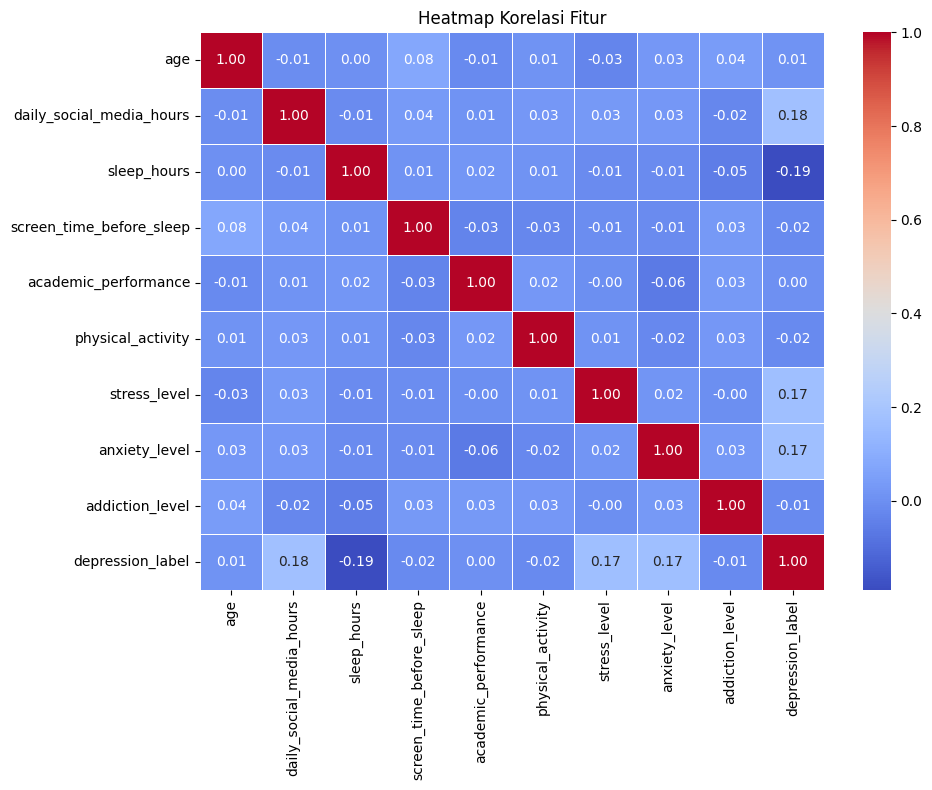

In [9]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()

In [10]:
df_clean = df.copy()

# Encoding fitur kategorikal
le = LabelEncoder()
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Pisahkan fitur dan target
X = df_clean.drop('depression_label', axis=1)
y = df_clean['depression_label']

print(f"\nFitur (X): {X.shape[1]} kolom")
print(f"Target (y): {y.value_counts().to_dict()}")

Encoded 'gender': {'female': np.int64(0), 'male': np.int64(1)}
Encoded 'platform_usage': {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}
Encoded 'social_interaction_level': {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Fitur (X): 12 kolom
Target (y): {0: 1169, 1: 31}


In [11]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Sebelum SMOTE : {dict(pd.Series(y).value_counts())}")
print(f"Sesudah SMOTE : {dict(pd.Series(y_resampled).value_counts())}")

Sebelum SMOTE : {0: np.int64(1169), 1: np.int64(31)}
Sesudah SMOTE : {0: np.int64(1169), 1: np.int64(1169)}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print(f"Data Train : {X_train.shape[0]} data")
print(f"Data Test  : {X_test.shape[0]} data")

# Normalisasi (wajib untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Data Train : 1870 data
Data Test  : 468 data


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest selesai ditraining!")

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    class_weight='balanced'
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print("✅ SVM selesai ditraining!")

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("✅ Decision Tree selesai!")

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
print("✅ Naive Bayes selesai!")

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print("✅ KNN selesai!")

✅ Random Forest selesai ditraining!
✅ SVM selesai ditraining!
✅ Decision Tree selesai!
✅ Naive Bayes selesai!
✅ KNN selesai!


In [15]:
def evaluasi_model(nama, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"{'='*45}")
    print(f"  HASIL EVALUASI: {nama}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Tidak Depresi', 'Depresi']))
    return {'Model': nama, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

hasil_rf  = evaluasi_model("Random Forest", y_test, y_pred_rf)
hasil_svm = evaluasi_model("SVM",           y_test, y_pred_svm)
hasil_dt  = evaluasi_model("Decision Tree", y_test, y_pred_dt)   # baru
hasil_nb  = evaluasi_model("Naive Bayes",   y_test, y_pred_nb)   # baru
hasil_knn = evaluasi_model("KNN",           y_test, y_pred_knn)  # baru

# Digabung semuanya jadi 5 di sini ↓
df_hasil = pd.DataFrame([
    hasil_rf,   # dari cell sebelumnya
    hasil_svm,  # dari cell sebelumnya
    hasil_dt,   # baru
    hasil_nb,   # baru
    hasil_knn   # baru
]).set_index('Model')

  HASIL EVALUASI: Random Forest
  Accuracy  : 1.0000 (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      1.00      1.00       234
      Depresi       1.00      1.00      1.00       234

     accuracy                           1.00       468
    macro avg       1.00      1.00      1.00       468
 weighted avg       1.00      1.00      1.00       468

  HASIL EVALUASI: SVM
  Accuracy  : 0.9936 (99.36%)
  Precision : 0.9873
  Recall    : 1.0000
  F1-Score  : 0.9936

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      0.99      0.99       234
      Depresi       0.99      1.00      0.99       234

     accuracy                           0.99       468
    macro avg       0.99      0.99      0.99       468
 weighted avg       0.99      0.99      0.99       468

  HASIL EVALUASI: Decision Tree
  Accurac

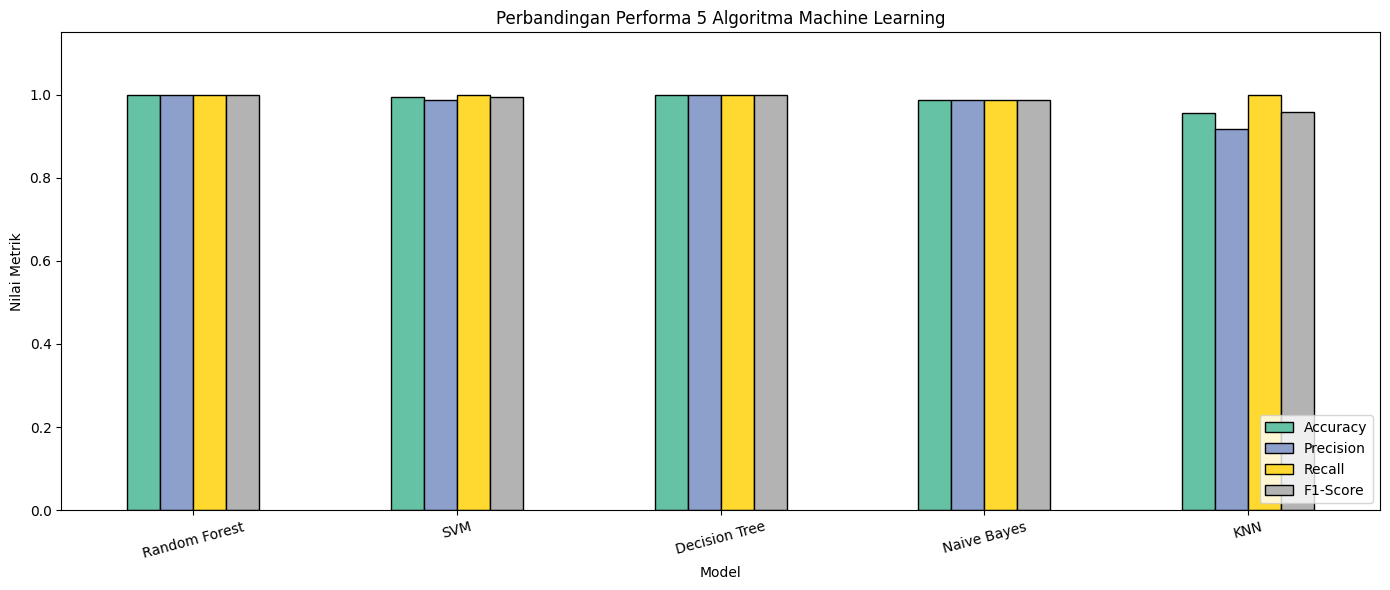

In [16]:
df_hasil.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa 5 Algoritma Machine Learning')
plt.ylabel('Nilai Metrik')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1.15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_5_model.png', dpi=150)
plt.show()


In [17]:
print("=== HYPERPARAMETER TUNING: Random Forest ===")
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_rf, cv=5, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print(f"Parameter terbaik RF : {grid_rf.best_params_}")
print(f"F1 terbaik RF        : {grid_rf.best_score_:.4f}")

print("\n=== HYPERPARAMETER TUNING: SVM ===")
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(
    SVC(random_state=42, class_weight='balanced'),
    param_svm, cv=5, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)
print(f"Parameter terbaik SVM: {grid_svm.best_params_}")
print(f"F1 terbaik SVM       : {grid_svm.best_score_:.4f}")

=== HYPERPARAMETER TUNING: Random Forest ===
Parameter terbaik RF : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
F1 terbaik RF        : 0.9995

=== HYPERPARAMETER TUNING: SVM ===
Parameter terbaik SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
F1 terbaik SVM       : 0.9942


In [18]:
# Prediksi dengan model hasil tuning
y_pred_rf_tuned  = grid_rf.best_estimator_.predict(X_test)
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_test_scaled)

hasil_rf_tuned  = evaluasi_model("RF (Tuned)",  y_test, y_pred_rf_tuned)
hasil_svm_tuned = evaluasi_model("SVM (Tuned)", y_test, y_pred_svm_tuned)

# Tabel perbandingan sebelum vs sesudah tuning
df_tuning = pd.DataFrame([
    hasil_rf, hasil_rf_tuned, hasil_svm, hasil_svm_tuned
]).set_index('Model')

print("\n=== SEBELUM vs SESUDAH TUNING ===")
print(df_tuning.to_string())

  HASIL EVALUASI: RF (Tuned)
  Accuracy  : 1.0000 (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      1.00      1.00       234
      Depresi       1.00      1.00      1.00       234

     accuracy                           1.00       468
    macro avg       1.00      1.00      1.00       468
 weighted avg       1.00      1.00      1.00       468

  HASIL EVALUASI: SVM (Tuned)
  Accuracy  : 0.9915 (99.15%)
  Precision : 0.9832
  Recall    : 1.0000
  F1-Score  : 0.9915

  Classification Report:
               precision    recall  f1-score   support

Tidak Depresi       1.00      0.98      0.99       234
      Depresi       0.98      1.00      0.99       234

     accuracy                           0.99       468
    macro avg       0.99      0.99      0.99       468
 weighted avg       0.99      0.99      0.99       468


=== SEBELUM vs SESUDAH TUNING ===
 

In [19]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'Random Forest' : (rf_model,  X_resampled),
    'SVM'           : (svm_model, scaler.transform(X_resampled)),
    'Decision Tree' : (dt_model,  X_resampled),
    'Naive Bayes'   : (nb_model,  scaler.transform(X_resampled)),
    'KNN'           : (knn_model, scaler.transform(X_resampled)),
}

print("=== CROSS VALIDATION 10-FOLD ===")
for nama, (model, X_cv) in models.items():
    cv_score = cross_val_score(model, X_cv, y_resampled, cv=kfold, scoring='f1')
    print(f"  {nama:<20} → F1: {cv_score.mean():.4f} (±{cv_score.std():.4f})")

=== CROSS VALIDATION 10-FOLD ===
  Random Forest        → F1: 0.9996 (±0.0013)
  SVM                  → F1: 0.9941 (±0.0057)
  Decision Tree        → F1: 0.9991 (±0.0017)
  Naive Bayes          → F1: 0.9907 (±0.0062)
  KNN                  → F1: 0.9618 (±0.0093)


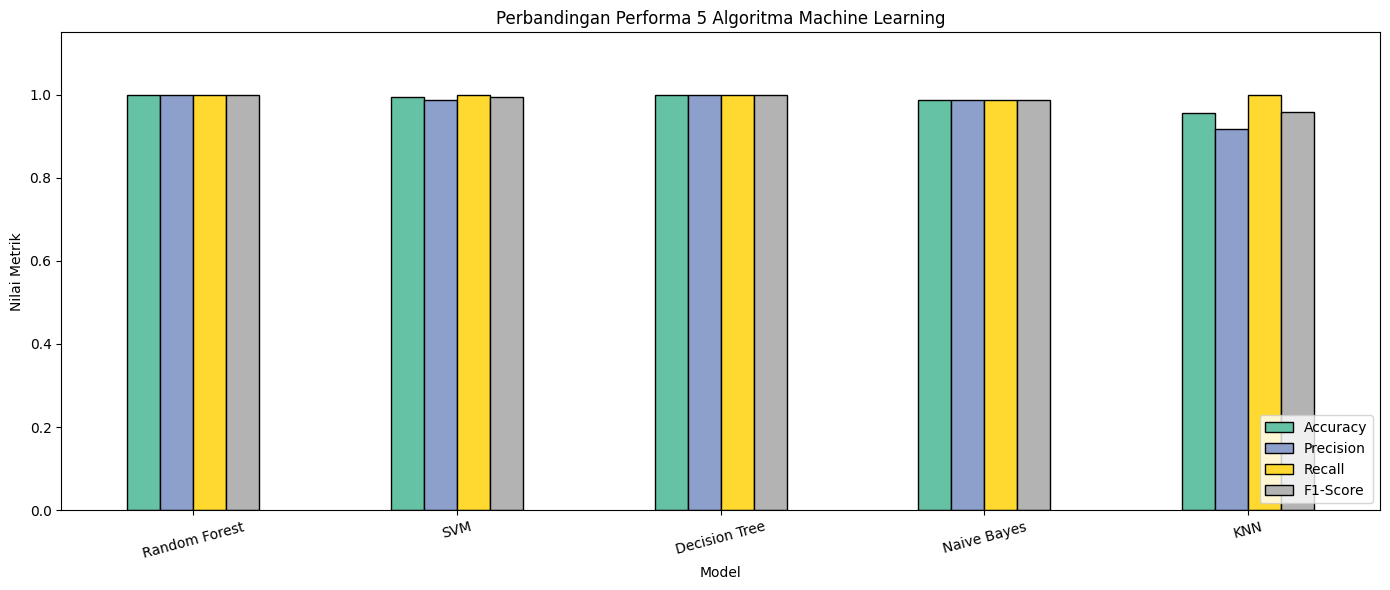

In [20]:
df_hasil.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Perbandingan Performa 5 Algoritma Machine Learning')
plt.ylabel('Nilai Metrik')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1.15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_5_model.png', dpi=150)
plt.show()

In [21]:
print("="*50)
print("  KESIMPULAN AKHIR")
print("="*50)

best = df_hasil['Accuracy'].idxmax()
worst = df_hasil['Accuracy'].idxmin()

print(f"\n✅ Model TERBAIK  : {best}")
print(f"   Accuracy  : {df_hasil.loc[best, 'Accuracy']*100:.2f}%")
print(f"   Precision : {df_hasil.loc[best, 'Precision']*100:.2f}%")
print(f"   Recall    : {df_hasil.loc[best, 'Recall']*100:.2f}%")
print(f"   F1-Score  : {df_hasil.loc[best, 'F1-Score']*100:.2f}%")

print(f"\n⚠️  Model TERENDAH : {worst}")
print(f"   Accuracy  : {df_hasil.loc[worst, 'Accuracy']*100:.2f}%")
print(f"   F1-Score  : {df_hasil.loc[worst, 'F1-Score']*100:.2f}%")

print("\n📁 File grafik tersimpan:")
for f in ['perbandingan_5_model.png', 'confusion_matrix.png', 'feature_importance.png']:
    print(f"   - {f}")

  KESIMPULAN AKHIR

✅ Model TERBAIK  : Random Forest
   Accuracy  : 100.00%
   Precision : 100.00%
   Recall    : 100.00%
   F1-Score  : 100.00%

⚠️  Model TERENDAH : KNN
   Accuracy  : 95.51%
   F1-Score  : 95.71%

📁 File grafik tersimpan:
   - perbandingan_5_model.png
   - confusion_matrix.png
   - feature_importance.png


In [23]:
print("=" * 55)
print("       KESIMPULAN AKHIR - PERBANDINGAN 5 MODEL")
print("=" * 55)

# Tabel lengkap semua nilai
print("\n📊 TABEL NILAI LENGKAP SEMUA ALGORITMA:")
print("-" * 55)
print(f"{'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>9}")
print("-" * 55)
for model_name, row in df_hasil.iterrows():
    print(f"{model_name:<20} {row['Accuracy']*100:>8.2f}% {row['Precision']*100:>9.2f}% {row['Recall']*100:>7.2f}% {row['F1-Score']*100:>8.2f}%")
print("-" * 55)

# Cari semua model dengan accuracy tertinggi
max_acc = df_hasil['Accuracy'].max()
best_models = df_hasil[df_hasil['Accuracy'] == max_acc].index.tolist()

print(f"\n🏆 Model TERBAIK (Accuracy {max_acc*100:.2f}%):")
for b in best_models:
    print(f"   ✅ {b}")
    print(f"      Precision : {df_hasil.loc[b, 'Precision']*100:.2f}%")
    print(f"      Recall    : {df_hasil.loc[b, 'Recall']*100:.2f}%")
    print(f"      F1-Score  : {df_hasil.loc[b, 'F1-Score']*100:.2f}%")

# Jika ada seri, tentukan pemenang berdasarkan F1-Score
if len(best_models) > 1:
    print(f"\n⚖️  Ada {len(best_models)} model dengan Accuracy sama!")
    print("   Penentu akhir menggunakan F1-Score:")
    best_f1 = df_hasil.loc[best_models, 'F1-Score'].idxmax()
    print(f"   🎯 Rekomendasi utama : {best_f1} (F1: {df_hasil.loc[best_f1, 'F1-Score']*100:.2f}%)")

# Model terendah
worst = df_hasil['Accuracy'].idxmin()
print(f"\n⚠️  Model TERENDAH : {worst}")
print(f"   Accuracy  : {df_hasil.loc[worst, 'Accuracy']*100:.2f}%")
print(f"   F1-Score  : {df_hasil.loc[worst, 'F1-Score']*100:.2f}%")

# Ranking
print("\n🏅 RANKING BERDASARKAN ACCURACY:")
print("-" * 35)
ranking = df_hasil['Accuracy'].sort_values(ascending=False)
medals = ['🥇', '🥈', '🥉', '4️⃣ ', '5️⃣ ']
for i, (nama, acc) in enumerate(ranking.items()):
    print(f"   {medals[i]} {nama:<20} : {acc*100:.2f}%")

       KESIMPULAN AKHIR - PERBANDINGAN 5 MODEL

📊 TABEL NILAI LENGKAP SEMUA ALGORITMA:
-------------------------------------------------------
Model                 Accuracy  Precision   Recall  F1-Score
-------------------------------------------------------
Random Forest          100.00%    100.00%  100.00%   100.00%
SVM                     99.36%     98.73%  100.00%    99.36%
Decision Tree          100.00%    100.00%  100.00%   100.00%
Naive Bayes             98.72%     98.72%   98.72%    98.72%
KNN                     95.51%     91.76%  100.00%    95.71%
-------------------------------------------------------

🏆 Model TERBAIK (Accuracy 100.00%):
   ✅ Random Forest
      Precision : 100.00%
      Recall    : 100.00%
      F1-Score  : 100.00%
   ✅ Decision Tree
      Precision : 100.00%
      Recall    : 100.00%
      F1-Score  : 100.00%

⚖️  Ada 2 model dengan Accuracy sama!
   Penentu akhir menggunakan F1-Score:
   🎯 Rekomendasi utama : Random Forest (F1: 100.00%)

⚠️  Model TEREND